In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [3]:
train_df = pd.read_csv("train_1.csv")
test_df = pd.read_csv("test_1.csv")

train_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
train_df.info()
train_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [5]:
train_df['Gender'] = train_df['Gender'].fillna(train_df['Gender'].mode()[0])
train_df['Married'] = train_df['Married'].fillna(train_df['Married'].mode()[0])
train_df['Dependents'] = train_df['Dependents'].fillna(train_df['Dependents'].mode()[0])
train_df['Self_Employed'] = train_df['Self_Employed'].fillna(train_df['Self_Employed'].mode()[0])

train_df['LoanAmount'] = train_df['LoanAmount'].fillna(train_df['LoanAmount'].median())
train_df['Loan_Amount_Term'] = train_df['Loan_Amount_Term'].fillna(train_df['Loan_Amount_Term'].mode()[0])
train_df['Credit_History'] = train_df['Credit_History'].fillna(train_df['Credit_History'].mode()[0])

In [6]:
train_df['LoanIncomeRatio'] = train_df['LoanAmount'] / train_df['ApplicantIncome']

In [7]:
train_df['Dependents'] = train_df['Dependents'].replace('3+',3)
train_df['Dependents'] = train_df['Dependents'].astype(int)

In [8]:
le = LabelEncoder()

categorical_cols = ['Gender','Married','Education','Self_Employed','Property_Area','Loan_Status']

for col in categorical_cols:
    train_df[col] = le.fit_transform(train_df[col])

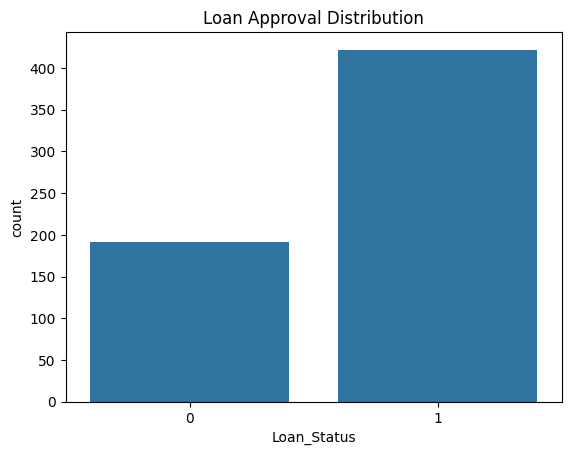

In [9]:
sns.countplot(x='Loan_Status', data=train_df)
plt.title("Loan Approval Distribution")
plt.show()

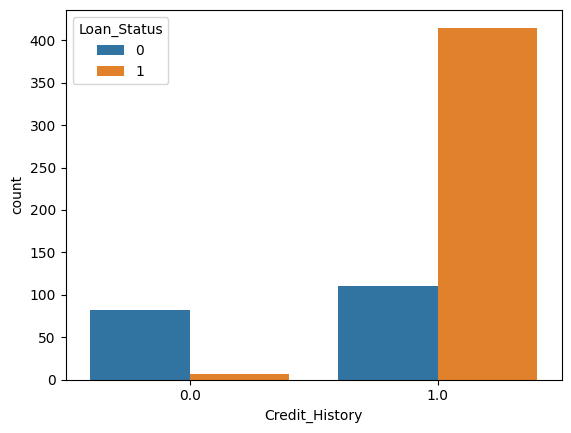

In [10]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=train_df)
plt.show()

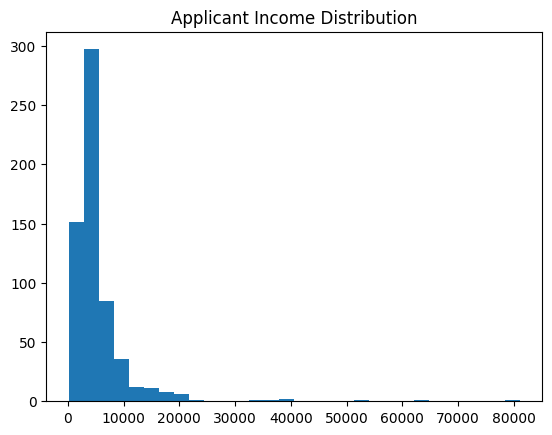

In [11]:
plt.hist(train_df['ApplicantIncome'], bins=30)
plt.title("Applicant Income Distribution")
plt.show()

In [12]:
X = train_df.drop(['Loan_ID','Loan_Status'], axis=1)
y = train_df['Loan_Status']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [14]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [15]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [16]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

In [17]:
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Decision Tree F1 Score:", f1_score(y_test, dt_pred))

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Random Forest F1 Score:", f1_score(y_test, rf_pred))

print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))
print("Gradient Boosting F1 Score:", f1_score(y_test, gb_pred))

Decision Tree Accuracy: 0.7479674796747967
Decision Tree F1 Score: 0.8143712574850299
Random Forest Accuracy: 0.7560975609756098
Random Forest F1 Score: 0.8333333333333334
Gradient Boosting Accuracy: 0.7723577235772358
Gradient Boosting F1 Score: 0.8444444444444444


In [18]:
test_df['Dependents'] = test_df['Dependents'].replace('3+',3)
test_df['Dependents'] = test_df['Dependents'].fillna(0)
test_df['Dependents'] = test_df['Dependents'].astype(int)

test_df['LoanAmount'] = test_df['LoanAmount'].fillna(test_df['LoanAmount'].median())
test_df['Loan_Amount_Term'] = test_df['Loan_Amount_Term'].fillna(test_df['Loan_Amount_Term'].mode()[0])
test_df['Credit_History'] = test_df['Credit_History'].fillna(test_df['Credit_History'].mode()[0])

In [19]:
test_df['LoanIncomeRatio'] = test_df['LoanAmount'] / test_df['ApplicantIncome']

In [20]:
categorical_cols_test = ['Gender','Married','Education','Self_Employed','Property_Area']

for col in categorical_cols_test:
    test_df[col] = le.fit_transform(test_df[col])

In [22]:
import numpy as np

# create feature
test_df['LoanIncomeRatio'] = test_df['LoanAmount'] / test_df['ApplicantIncome']

# replace infinity values
test_df.replace([np.inf, -np.inf], 0, inplace=True)

In [23]:
best_model = rf

predictions = best_model.predict(test_df.drop('Loan_ID', axis=1))

In [24]:
loan_status = ['Y' if p == 1 else 'N' for p in predictions]

In [28]:
submission = pd.DataFrame({
    'Loan_ID': test_df['Loan_ID'],
    'Loan_Status': loan_status
})

submission.head()

,Loan_ID,Loan_Status
0,LP001015,Y
1,LP001022,Y
2,LP001031,Y
3,LP001035,Y
4,LP001051,N
